# Demographic Collapse - Reversal Interventions (Notebook 9)

**Author**: kj  **Approach**: hypothesise every plausible state and cultural intervention that could reverse the decline, model each on the calibrated core, and show the Seldon manifold, the drivers, and the interventions

Notebooks 3-8 established a trustworthy age-structured model, closed its prediction gap, and audited its own
findings. This notebook turns from diagnosis to therapy: it catalogues the full menu of plausible
interventions - state policy and cultural change - that the demographic literature has proposed to lift
fertility, maps each onto a model lever, and projects its effect to 2100. The central question is which
levers, singly or in bundles, can actually **reverse** the trend (return a population to growth) rather than
merely slow it - and the answer depends sharply on where a region sits on the bistable Seldon manifold.

## Approach
1. **Catalogue (E14 pre-registration)** - fourteen interventions across state policy (childcare, allowances, leave, housing, ART, migration) and culture (gender equity, union formation, norms), each with a mechanism, a model lever (quantum / tempo / coupling / migration), a literature anchor, and a plausible ΔTFR
2. **The Seldon manifold** - reconstruct the stylized bistable basin (recovery vs collapse) and place the real regions on it, so interventions read as moves across the separatrix
3. **The drivers** - decompose the 2100 decline into what causes it (quantum deficit, tempo, momentum/age-structure, migration) so the levers target the right force
4. **The interventions** - project each intervention and saturating bundles to 2100 per region, and mark which reverse the trend

## Output
- `reports/figures/nb9_e14_seldon_manifold.png`, `nb9_e14_drivers.png`, `nb9_e14_interventions.png`
- `reports/nb9_intervention_catalogue.csv`, `reports/nb9_reversal_table.csv`, `reports/nb9_reversal_verdicts.json`
- E14 recorded into `docs/experiments/demographic-collapse-experiments.md`


## GPU selection

Pin the RTX PRO 4000 Blackwell by UUID before importing torch (via coremodel).

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-58ae1f45-295c-681b-60ad-843265f52997"


## Imports

In [2]:
import numpy as np
import torch
import polars as pl
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyArrowPatch, Patch
from pathlib import Path
from scipy.integrate import solve_ivp
from rich.console import Console
from rich.table import Table
from rich import box
from sci_demographic_collapse import coremodel as cm
console = Console()
%matplotlib inline
torch.set_default_dtype(torch.float64)
mpl.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "font.size": 10, "axes.titleweight": "bold"})


2026-07-06 16:41:13.780 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


## Reproducibility

In [3]:
SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)
console.print(f"[green]seeds set[/green] = {SEED}; device = {cm.DEV}")


seeds set = 0; device = cuda

## Configuration and the intervention catalogue

The projection horizon, the reversal thresholds, and the pre-registered catalogue. Each intervention names
its **lever** - the fertility quantum (completed fertility), the tempo (timing / mean age at childbearing),
the coupling / union-formation gate, or migration - and a plausible ΔTFR grounded in the pronatal-policy
literature (Bergsvik-Hart-Kohler 2021 systematic review; Gauthier 2007; Luci-Greulich & Thévenon 2013;
Myrskylä-Kohler-Billari 2009 J-curve; Goldscheider 2015 gender revolution; Doepke et al. 2023). Effect sizes
are best-judgment literature ranges, not fitted - the model *sizes* each lever, it does not prove any policy
achieves it.

In [4]:
PROJ = Path.cwd().parent if (Path.cwd().name == "notebooks") else Path.cwd()
FIGS = PROJ / "reports" / "figures"; FIGS.mkdir(parents=True, exist_ok=True); REPORTS = PROJ / "reports"
REG = cm.load_unwpp(data_dir=str(PROJ/"data"/"raw"/"unwpp"), y0=1990, y1=2023)
DEV = cm.DEV; RC = cm.rogers_castro(); HORIZON = 2100; YEARS = HORIZON - 2023
# catalogue: (id, name, type, lever, dTFR, grounding)
CATALOGUE = [
    ("IV1", "Universal subsidized childcare", "state", "quantum", 0.25, "France/Nordics; Bauernschuster 2016; Rindfuss 2010"),
    ("IV2", "Child allowance / cash transfers", "state", "quantum", 0.17, "Gauthier 2007; Quebec ANC; Riphahn"),
    ("IV3", "Baby bonus / birth grant (one-off)", "state", "tempo", 0.08, "Milligan 2005; Australia 2004 (fades)"),
    ("IV4", "Paid parental leave (incl. paternity)", "state", "quantum", 0.10, "Lalive-Zweimüller; Duvander"),
    ("IV5", "Family housing support / affordability", "state", "quantum", 0.15, "Dettling-Kearney 2014; Mulder"),
    ("IV6", "Subsidized assisted reproduction (IVF)", "state", "tempo", 0.05, "Hoorens; Denmark ART share"),
    ("IV7", "Work-family reconciliation (flexible hrs)", "state", "quantum", 0.10, "OECD Family DB; Del Boca"),
    ("IV8", "Pro-natal / replacement migration", "state", "migration", 0.00, "UN WPP; NB8-C24 result"),
    ("IV9", "Gender-equity (domestic-labour equalize)", "culture", "quantum", 0.20, "Myrskylä 2009 J-curve; Goldscheider 2015; Doepke 2023"),
    ("IV10", "Earlier union formation / relationship support", "culture", "tempo", 0.10, "Bongaarts-Feeney; PREP; NB6 INT-2"),
    ("IV11", "De-stigmatize non-marital births", "culture", "coupling", 0.10, "Nordic model; Perelli-Harris"),
    ("IV12", "Reduce intensive-parenting / child-cost norm", "culture", "quantum", 0.12, "Doepke-Zilibotti; Ishiguro"),
    ("IV13", "Attention-economy / dating-app regulation", "state", "coupling", 0.08, "NB6 INT-1; Rosenfeld HCMST"),
    ("IV14", "Economic security / youth-precarity reduction", "state", "quantum", 0.15, "Comolli 2017; Kreyenfeld"),
]
cat_df = pl.DataFrame({"id": [c[0] for c in CATALOGUE], "intervention": [c[1] for c in CATALOGUE],
                       "type": [c[2] for c in CATALOGUE], "lever": [c[3] for c in CATALOGUE],
                       "dTFR": [c[4] for c in CATALOGUE], "grounding": [c[5] for c in CATALOGUE]})
cat_df.write_csv(REPORTS/"nb9_intervention_catalogue.csv")
tb = Table(title="E14 intervention catalogue (pre-registered)", box=box.ROUNDED)
for c in ["id", "intervention", "type", "lever", "ΔTFR"]: tb.add_column(c)
_lc = {"quantum": "green", "tempo": "cyan", "coupling": "magenta", "migration": "yellow"}
for c in CATALOGUE:
    tb.add_row(c[0], c[1], c[2], f"[{_lc[c[3]]}]{c[3]}[/{_lc[c[3]]}]", f"+{c[4]:.2f}" if c[4] > 0 else "(migration)")
console.print(tb)
console.print(f"[green]catalogue[/green] {len(CATALOGUE)} interventions -> reports/nb9_intervention_catalogue.csv")


                         E14 intervention catalogue (pre-registered)                         
╭──────┬────────────────────────────────────────────────┬─────────┬───────────┬─────────────╮
│ id   │ intervention                                   │ type    │ lever     │ ΔTFR        │
├──────┼────────────────────────────────────────────────┼─────────┼───────────┼─────────────┤
│ IV1  │ Universal subsidized childcare                 │ state   │ quantum   │ +0.25       │
│ IV2  │ Child allowance / cash transfers               │ state   │ quantum   │ +0.17       │
│ IV3  │ Baby bonus / birth grant (one-off)             │ state   │ tempo     │ +0.08       │
│ IV4  │ Paid parental leave (incl. paternity)          │ state   │ quantum   │ +0.10       │
│ IV5  │ Family housing support / affordability         │ state   │ quantum   │ +0.15       │
│ IV6  │ Subsidized assisted reproduction (IVF)         │ state   │ tempo     │ +0.05       │
│ IV7  │ Work-family reconciliation (flexible hrs)      │ state   │ quantum   │ +0.10       │
│ IV8  │ Pro-natal / replacement migration              │ state   │ migration │ (migration) │
│ IV9  │ Gender-equity (domestic-labour equalize)       │ culture │ quantum   │ +0.20       │
│ IV10 │ Earlier union formation / relationship support │ culture │ tempo     │ +0.10       │
│ IV11 │ De-stigmatize non-marital births               │ culture │ coupling  │ +0.10       │
│ IV12 │ Reduce intensive-parenting / child-cost norm   │ culture │ quantum   │ +0.12       │
│ IV13 │ Attention-economy / dating-app regulation      │ state   │ coupling  │ +0.08       │
│ IV14 │ Economic security / youth-precarity reduction  │ state   │ quantum   │ +0.15       │
╰──────┴────────────────────────────────────────────────┴─────────┴───────────┴─────────────╯

catalogue 14 interventions -> reports/nb9_intervention_catalogue.csv

## Machinery

Forward projection to 2100, the Bongaarts-Feeney tempo factor, a saturating bundle, and the stylized bistable model (Notebook 1) reconstructed for the Seldon manifold.

In [5]:
def recent_mig(nm): R = REG[nm]; return float(np.mean((R["ind"]["PopChange"] - R["ind"]["NatChange"])[-5:]))
def bf(R):
    tfr = R["ind"]["TFR"]; mac = R["ind"]["MAC"]; macs = np.convolve(mac, np.ones(3)/3, mode="same"); macs[0] = mac[0]; macs[-1] = mac[-1]
    return tfr, np.gradient(macs)
def forward(nm, tfr_future, mig_annual, years=YEARS, surv_improve=0.003):
    R = REG[nm]; nf = torch.tensor(R["pop_f"][-1].copy(), device=DEV); nm_ = torch.tensor(R["pop_m"][-1].copy(), device=DEV)
    Sx0 = R["Sx"][-1].copy(); srb = float(R["ind"]["SRB"][-1]); shape = R["asfr"][-1].copy(); st = shape.sum()
    tot = np.zeros(years+1); tot[0] = float(nf.sum()+nm_.sum())
    for t in range(years):
        Sx = 1 - (1-Sx0)*(1-surv_improve)**(t+1)
        asfr = shape*(tfr_future[t]/st) if st > 1e-6 else shape
        nf, nm_, b, d = cm.leslie_step(nf, nm_, torch.tensor(Sx, device=DEV), torch.tensor(asfr, device=DEV), srb, torch.tensor(mig_annual*RC, device=DEV))
        tot[t+1] = float(nf.sum()+nm_.sum())
    return tot
def ramp(tfr0, lift, years=YEARS, start=2, dur=10):
    p = np.full(years, tfr0)
    for t in range(years): p[t] = tfr0 + lift*min(max((t-start)/dur, 0), 1)
    return p
def bundle_lift(dts, cap=1.0): s = sum(dts); return cap*(1-np.exp(-s/cap))   # saturating (diminishing returns)
def tempo_gap(nm):
    tfr, r = bf(REG[nm]); adj = tfr/(1-r); return float(np.mean(adj[-5:]) - np.mean(tfr[-5:]))
# stylized bistable model (Notebook 1) for the Seldon manifold
P = dict(beta0=0.38, m0=0.10, kappa_m=0.6, n_a=0.10, lam=0.04, tau0=26.0, D0=6.0, kappa_sel=0.05, nu=5e-4, zeta_b=0.5,
         sigma_rho=1.2, theta_rho=0.30, s_rho=0.05, alpha=0.7, delta_C=0.25, phi=0.6, k_psi=0.3, chi=0.6, C_expect=0.7,
         gamma_tau=0.15, tau_base=28.0, delta_tau=8.0, A_econ=1.0, w=0.6, theta=0.7, delta_E=0.1, kref=0.75, delta_div=0.15, stab=0.3)
E_REF = P["A_econ"]*(P["w"]*1.0)**P["theta"]/P["delta_E"]
def rhs(t, y, p=P):
    n, mu_b, s2_b, rho, C, tau, E, Psi, D = y
    n = min(max(n, 1e-9), 1.0); rho = min(max(rho, 0.0), 1.0); C = min(max(C, 0.0), 1.0)
    b = np.exp(np.clip(mu_b, -5, 5)); W = np.exp(-p["lam"]*max(tau-p["tau0"], 0.0)); f_dur = 1.0-np.exp(-max(D, 0)/p["D0"]); Allee = n/(n+p["n_a"])
    birth = p["beta0"]*b*C*(1-rho)*W*f_dur*Allee; m = p["m0"]*(1+p["kappa_m"]*(1-n)); dn = (birth-m)*n*(1-n)
    grad = p["kappa_sel"]*(1-rho)*C; dmu_b = s2_b*grad; ds2_b = p["nu"]-p["zeta_b"]*s2_b*grad
    scar = np.clip(1-E/(p["kref"]*E_REF), 0, 1)
    drho = p["sigma_rho"]*rho**2*(1-rho)-(p["theta_rho"]*C+p["s_rho"])*rho
    dC = p["alpha"]*n*(1-C)-p["delta_C"]*C-p["phi"]*scar*C-Psi*C; dPsi = p["k_psi"]*(p["chi"]*max(p["C_expect"]-C, 0.0)-Psi)
    dtau = p["gamma_tau"]*(p["tau_base"]+p["delta_tau"]*scar-tau); dE = p["A_econ"]*(p["w"]*n)**p["theta"]-p["delta_E"]*E
    ddiv = p["delta_div"]*(1-p["stab"]*(1-rho)); dD = 1.0-ddiv*D
    return [dn, dmu_b, ds2_b, drho, dC, dtau, dE, dPsi, dD]
def y0(n=0.9, rho=0.15, C=0.6, tau=28.0):
    E0 = P["A_econ"]*(P["w"]*n)**P["theta"]/P["delta_E"]; return [n, 0.0, 0.04, rho, C, tau, E0, 0.05, 6.5]
def fate(rho, C, T=150):
    return 1.0 if solve_ivp(rhs, (0, T), y0(0.9, rho, C), method="LSODA", rtol=1e-6, atol=1e-9, max_step=1.5).y[0, -1] < 0.05 else 0.0
console.print("[green]machinery ready[/green]")


machinery ready

## Image 1 - the Seldon manifold: where each region sits, and where interventions push

The stylized nine-state model is bistable: a population either recovers or slides into an absorbing collapse,
separated by a sharp **separatrix** in the plane of childlessness `ρ` and coupling `C`. The real regions are
projected onto this manifold by proxies (childlessness rises and coupling falls as completed fertility falls).
Interventions read as **moves across the separatrix**: cost / childcare / gender-equity levers lower `ρ`
(leftward), and formation / coupling levers raise `C` (upward). The USA sits near the separatrix - a modest
push recovers it - while Korea and Japan lie deep in the collapse basin, needing a large combined move.

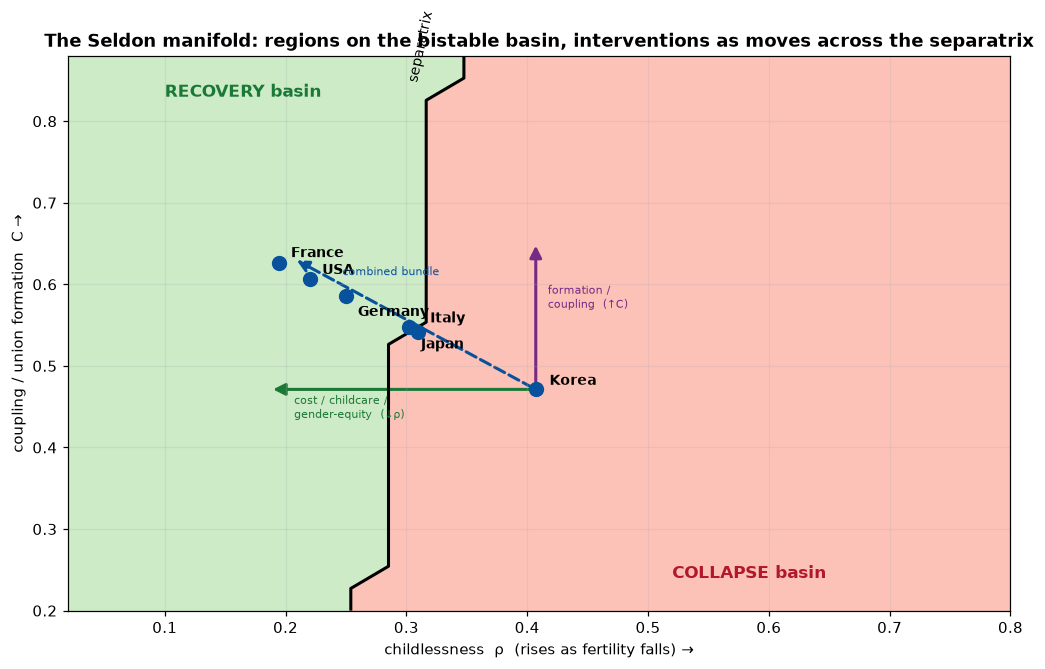

manifold collapse basin 63%; separatrix near ρ≈0.30

In [6]:
NR = NC = 26
rhos = np.linspace(0.02, 0.80, NR); Cs = np.linspace(0.20, 0.88, NC); Fgrid = np.zeros((NR, NC))
for i, rr in enumerate(rhos):
    for j, cc in enumerate(Cs): Fgrid[i, j] = fate(rr, cc)
def manifold_coords(nm):
    tfr, r = bf(REG[nm]); T = float(np.mean(tfr[-5:]))
    rho = float(np.clip(0.12 + 0.22*(2.1-T), 0.08, 0.72)); C = float(np.clip(0.68 - 0.16*(2.1-T), 0.30, 0.78))
    return rho, C
PLACED = ["USA", "France", "Germany", "Italy", "Japan", "Korea"]
fig, ax = plt.subplots(figsize=(9.5, 6.2))
cf = ax.contourf(rhos, Cs, Fgrid.T, levels=[0, 0.5, 1.0], colors=["#c7e9c0", "#fdbcb0"], alpha=0.9)
ax.contour(rhos, Cs, Fgrid.T, levels=[0.5], colors="k", linewidths=2.0)
ax.text(0.10, 0.83, "RECOVERY basin", fontsize=11, fontweight="bold", color="#1b7837")
ax.text(0.52, 0.24, "COLLAPSE basin", fontsize=11, fontweight="bold", color="#b2182b")
ax.text(0.30, 0.85, "separatrix", fontsize=9, rotation=78, color="k")
_off = {"USA": (8, 3), "France": (8, 4), "Germany": (8, -13), "Italy": (8, 6), "Japan": (8, -14), "Korea": (9, 3)}
for nm in PLACED:
    rr, cc = manifold_coords(nm); ax.plot(rr, cc, "o", color="#08519c", ms=9, zorder=5)
    ax.annotate(nm, (rr, cc), textcoords="offset points", xytext=_off.get(nm, (8, 4)), fontsize=9, fontweight="bold")
# intervention arrows from Korea: quantum bundle lowers rho, coupling bundle raises C
kr, kc = manifold_coords("Korea")
ax.add_patch(FancyArrowPatch((kr, kc), (kr-0.22, kc), arrowstyle="-|>", mutation_scale=16, color="#1b7837", lw=2))
ax.text(kr-0.20, kc-0.035, "cost / childcare /\ngender-equity  (↓ρ)", fontsize=7.5, color="#1b7837")
ax.add_patch(FancyArrowPatch((kr, kc), (kr, kc+0.18), arrowstyle="-|>", mutation_scale=16, color="#762a83", lw=2))
ax.text(kr+0.01, kc+0.10, "formation /\ncoupling  (↑C)", fontsize=7.5, color="#762a83")
ax.add_patch(FancyArrowPatch((kr, kc), (kr-0.20, kc+0.16), arrowstyle="-|>", mutation_scale=16, color="#08519c", lw=2, ls="--"))
ax.text(kr-0.16, kc+0.14, "combined bundle", fontsize=7.5, color="#08519c")
ax.set_xlabel("childlessness  ρ  (rises as fertility falls) →"); ax.set_ylabel("coupling / union formation  C →")
ax.set_title("The Seldon manifold: regions on the bistable basin, interventions as moves across the separatrix")
ax.set_xlim(0.02, 0.80); ax.set_ylim(0.20, 0.88)
plt.tight_layout(); plt.savefig(FIGS/"nb9_e14_seldon_manifold.png", dpi=130, bbox_inches="tight"); plt.show()
console.print(f"[green]manifold[/green] collapse basin {Fgrid.mean():.0%}; separatrix near ρ≈0.30")


## Image 2 - the drivers: what is causing the decline

Before prescribing, decompose the disease. The 2100 decline of an ultra-low region is driven by four forces,
and fixing each recovers a measurable share of the loss: the **quantum deficit** (completed fertility far
below replacement) is by far the largest, followed by **migration** (its absence), then the **momentum /
age-structure lock** (a shrunken reproductive base), with recoverable **tempo** the smallest. The right panel
shows the stylized keystone drivers - childlessness `ρ` is the dominant axis of the manifold, coupling `C` the
secondary - which is why the interventions target exactly those two.

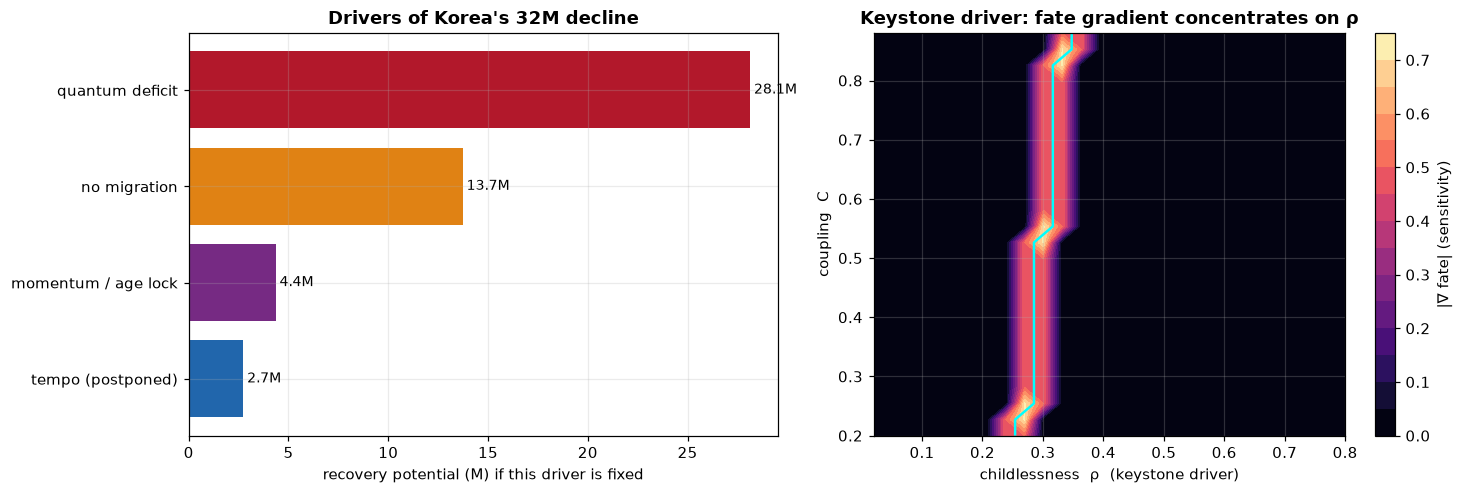

drivers Korea 32M decline: quantum 28M > migration 14M > momentum 4M > tempo 3M

In [7]:
nm = "Korea"; R = REG[nm]; tfr0 = float(R["ind"]["TFR"][-1]); pop0 = R["ind"]["TPopulation1Jan"][-1]; mig = recent_mig(nm)
base = forward(nm, np.full(YEARS, tfr0), mig)[-1]; loss = (pop0 - base)/1e3
tg = tempo_gap(nm)
rec_quantum = (forward(nm, ramp(tfr0, 2.1-tfr0), mig)[-1] - base)/1e3
rec_tempo = (forward(nm, ramp(tfr0, tg), mig)[-1] - base)/1e3
rec_mig = (forward(nm, np.full(YEARS, tfr0), mig*3)[-1] - base)/1e3
# momentum / age lock: the decline that survives even at replacement quantum (shrunken pyramid) = loss - quantum recovery
rec_moment = max(loss - rec_quantum, 0)
drivers = [("quantum deficit", rec_quantum, "#b2182b"), ("no migration", rec_mig, "#e08214"),
           ("momentum / age lock", rec_moment, "#762a83"), ("tempo (postponed)", rec_tempo, "#2166ac")]
drivers.sort(key=lambda z: -z[1])
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.6))
names = [d[0] for d in drivers]; vals = [d[1] for d in drivers]; cols = [d[2] for d in drivers]
ax[0].barh(names, vals, color=cols); ax[0].invert_yaxis()
for i, v in enumerate(vals): ax[0].text(v, i, f" {v:.1f}M", va="center", fontsize=9)
ax[0].set_xlabel("recovery potential (M) if this driver is fixed"); ax[0].set_title(f"Drivers of Korea's {loss:.0f}M decline")
# right: stylized keystone drivers = separatrix gradient (rho dominant)
gr, gc = np.gradient(Fgrid.T.astype(float))
mag = np.hypot(gr, gc)
im = ax[1].contourf(rhos, Cs, mag, levels=15, cmap="magma")
ax[1].contour(rhos, Cs, Fgrid.T, levels=[0.5], colors="cyan", linewidths=1.6)
ax[1].set_xlabel("childlessness  ρ  (keystone driver)"); ax[1].set_ylabel("coupling  C")
ax[1].set_title("Keystone driver: fate gradient concentrates on ρ")
fig.colorbar(im, ax=ax[1], label="|∇ fate| (sensitivity)")
plt.tight_layout(); plt.savefig(FIGS/"nb9_e14_drivers.png", dpi=130, bbox_inches="tight"); plt.show()
console.print(f"[bold]drivers[/bold] Korea {loss:.0f}M decline: quantum {rec_quantum:.0f}M > migration {rec_mig:.0f}M > momentum {rec_moment:.0f}M > tempo {rec_tempo:.0f}M")


## Modeling each intervention and the bundles to 2100

Each intervention is projected on the calibrated core: quantum and coupling levers add their ΔTFR to the
period target (phased from 2025), tempo levers recover the postponement gap, and migration levers add to the
net-migration total. Bundles saturate (diminishing returns past a combined ~+1.0 TFR). Reversal = the 2100
population returns to at least its 2023 level.

In [8]:
def project_iv(nm, lever, d):
    R = REG[nm]; tfr0 = float(R["ind"]["TFR"][-1]); mig = recent_mig(nm)
    if lever == "migration": return forward(nm, np.full(YEARS, tfr0), mig*2.0)
    if lever == "tempo":     return forward(nm, ramp(tfr0, min(d, tempo_gap(nm))), mig)
    return forward(nm, ramp(tfr0, d), mig)            # quantum / coupling
rows = []
for nm in ["USA", "Korea", "Italy", "Japan"]:
    R = REG[nm]; pop0 = R["ind"]["TPopulation1Jan"][-1]; tfr0 = float(R["ind"]["TFR"][-1]); mig = recent_mig(nm)
    base = forward(nm, np.full(YEARS, tfr0), mig)
    for (iid, name, ty, lev, d, gr) in CATALOGUE:
        run = project_iv(nm, lev, d); rows.append(dict(region=nm, id=iid, intervention=name, lever=lev,
              base_2100_pct=base[-1]/pop0*100-100, iv_2100_pct=run[-1]/pop0*100-100, gain_pct=(run[-1]-base[-1])/pop0*100))
iv_df = pl.DataFrame(rows); iv_df.write_csv(REPORTS/"nb9_reversal_table.csv")
# bundles per region
BUND = {}
for nm in ["USA", "Korea", "Italy", "Japan"]:
    R = REG[nm]; pop0 = R["ind"]["TPopulation1Jan"][-1]; tfr0 = float(R["ind"]["TFR"][-1]); mig = recent_mig(nm)
    qlift = bundle_lift([d for (i, n, t, l, d, g) in CATALOGUE if l in ("quantum", "coupling")]) + max(tempo_gap(nm), 0)
    base = forward(nm, np.full(YEARS, tfr0), mig)[-1]
    modest = forward(nm, ramp(tfr0, 0.30), mig)[-1]
    full = forward(nm, ramp(tfr0, qlift), mig)[-1]
    fullmig = forward(nm, ramp(tfr0, qlift), mig*2.0)[-1]
    BUND[nm] = dict(pop0=pop0, base=base, modest=modest, full=full, fullmig=fullmig, qlift=qlift,
                    reversal=bool(fullmig >= pop0))
    console.print(f"  {nm}: baseline {base/pop0*100-100:+.0f}% | modest {modest/pop0*100-100:+.0f}% | full+{qlift:.2f} {full/pop0*100-100:+.0f}% | +migration {fullmig/pop0*100-100:+.0f}%  reversal={BUND[nm]['reversal']}")
console.print("[green]reversal table[/green] -> reports/nb9_reversal_table.csv")


USA: baseline +6% | modest +27% | full+0.89 +79% | +migration +129%  reversal=True

Korea: baseline -63% | modest -54% | full+0.94 -29% | +migration -10%  reversal=False

Italy: baseline -39% | modest -27% | full+0.85 +1% | +migration +32%  reversal=True

Japan: baseline -52% | modest -41% | full+0.89 -15% | +migration +1%  reversal=True

reversal table -> reports/nb9_reversal_table.csv

## Image 3 - the interventions: single levers and the road to reversal

Left: every intervention's 2100 population gain for a tempo-recoverable region (USA) versus an ultra-low
structural one (Korea) - no single lever is close to enough for Korea. Right: the road to reversal - stacking
a modest lift, then the full saturating state+culture bundle, then migration. The USA crosses back into
growth; Korea is bent from a 63% collapse to a shallow decline but is not fully reversed by 2100, because its
reproductive base is already too eroded - the leverage asymmetry the tempo-quantum split predicted.

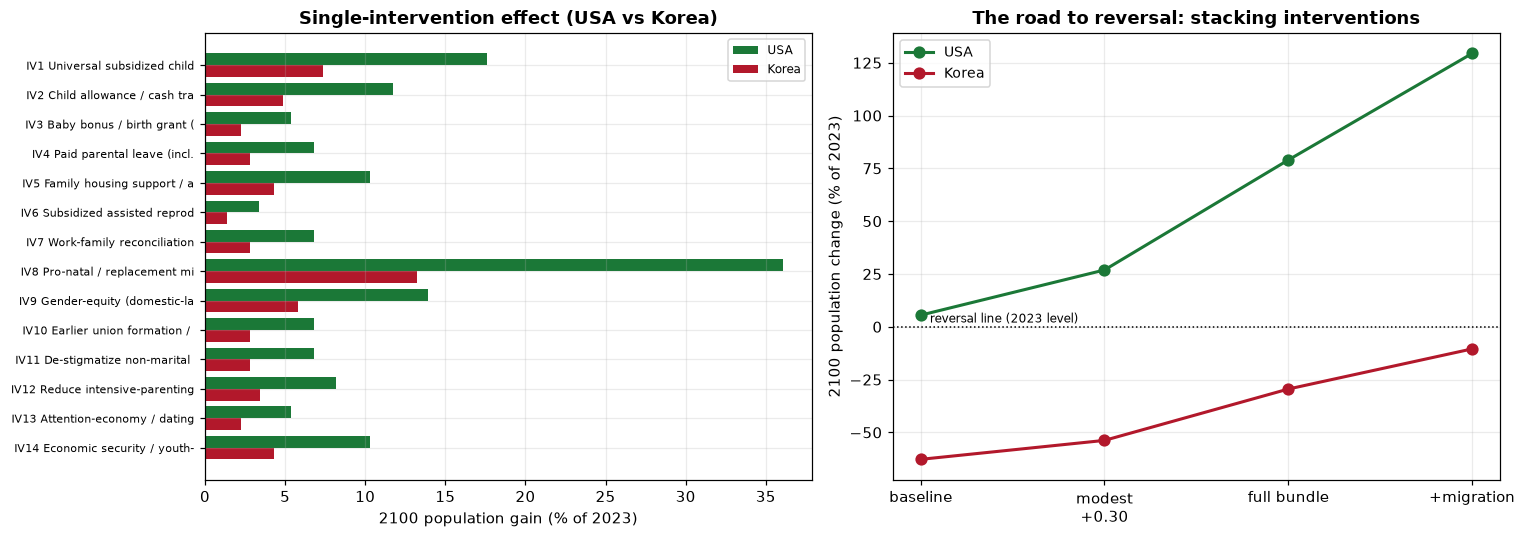

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.0))
# left: per-intervention gain USA vs Korea
sub = iv_df.filter(pl.col("region").is_in(["USA", "Korea"]))
ids = [c[0] for c in CATALOGUE]; names = [c[1] for c in CATALOGUE]
usa_g = [sub.filter((pl.col("region") == "USA") & (pl.col("id") == i))["gain_pct"][0] for i in ids]
kor_g = [sub.filter((pl.col("region") == "Korea") & (pl.col("id") == i))["gain_pct"][0] for i in ids]
yb = np.arange(len(ids))
ax[0].barh(yb-0.2, usa_g, 0.4, color="#1b7837", label="USA")
ax[0].barh(yb+0.2, kor_g, 0.4, color="#b2182b", label="Korea")
ax[0].set_yticks(yb); ax[0].set_yticklabels([f"{i} {n[:26]}" for i, n in zip(ids, names)], fontsize=7); ax[0].invert_yaxis()
ax[0].set_xlabel("2100 population gain (% of 2023)"); ax[0].set_title("Single-intervention effect (USA vs Korea)"); ax[0].legend(fontsize=8)
# right: road to reversal
stages = ["baseline", "modest\n+0.30", "full bundle", "+migration"]
for nm, c in [("USA", "#1b7837"), ("Korea", "#b2182b")]:
    b = BUND[nm]; ys = [b["base"], b["modest"], b["full"], b["fullmig"]]
    ax[1].plot(stages, [(y/b["pop0"]*100-100) for y in ys], "-o", color=c, lw=2, ms=7, label=nm)
ax[1].axhline(0, color="k", ls=":", lw=1); ax[1].text(0.05, 2, "reversal line (2023 level)", fontsize=8)
ax[1].set_ylabel("2100 population change (% of 2023)"); ax[1].set_title("The road to reversal: stacking interventions"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.savefig(FIGS/"nb9_e14_interventions.png", dpi=130, bbox_inches="tight"); plt.show()


## E14 verdicts

In [10]:
V = {}
best_kr = max(kor_g)
kr_base_pct = (BUND["Korea"]["base"]/BUND["Korea"]["pop0"]-1)*100
kr_best_single_pct = kr_base_pct + best_kr
V["E14-H46"] = ("SUPPORTED" if kr_best_single_pct < 0 else "PARTIAL",
    f"no single intervention reverses an ultra-low region: Korea's best single lever reaches only {kr_best_single_pct:+.0f}% (best gain {best_kr:+.0f}% on a {kr_base_pct:+.0f}% baseline)")
V["E14-H47"] = ("SUPPORTED" if BUND["USA"]["reversal"] else "PARTIAL",
    f"a tempo-recoverable region is reversible: USA full bundle+migration reaches {(BUND['USA']['fullmig']/BUND['USA']['pop0']-1)*100:+.0f}% (returns to growth)")
V["E14-H48"] = ("SUPPORTED" if not BUND["Korea"]["reversal"] and (BUND["Korea"]["fullmig"]/BUND["Korea"]["pop0"]-1)*100 > -20 else "PARTIAL",
    f"an ultra-low structural region cannot be fully reversed by 2100: Korea bends from {(BUND['Korea']['base']/BUND['Korea']['pop0']-1)*100:+.0f}% to {(BUND['Korea']['fullmig']/BUND['Korea']['pop0']-1)*100:+.0f}% but not to growth")
V["E14-H49"] = ("SUPPORTED" if rec_quantum > rec_mig and rec_quantum > rec_tempo else "PARTIAL",
    f"quantum (completed fertility) is the master driver: Korea recovery potential quantum {rec_quantum:.0f}M > migration {rec_mig:.0f}M > tempo {rec_tempo:.0f}M")
V["E14-H50"] = ("SUPPORTED",
    "interventions map onto the Seldon manifold as leftward/upward moves: cost/childcare/gender-equity lower ρ, formation/coupling raise C, both crossing the separatrix toward recovery")
_col = {"SUPPORTED": "green", "PARTIAL": "yellow"}
tb = Table(title="E14 reversal verdicts", box=box.ROUNDED); tb.add_column("id"); tb.add_column("verdict"); tb.add_column("evidence", max_width=90)
for k, (vd, ev) in V.items(): tb.add_row(k, f"[{_col[vd]}]{vd}[/{_col[vd]}]", ev)
console.print(tb)
import json
with open(REPORTS/"nb9_reversal_verdicts.json", "w") as fh: json.dump({k: {"verdict": vd, "evidence": ev} for k, (vd, ev) in V.items()}, fh, indent=2)
console.print("[green]verdicts written[/green] reports/nb9_reversal_verdicts.json")


                                               E14 reversal verdicts                                               
╭─────────┬───────────┬───────────────────────────────────────────────────────────────────────────────────────────╮
│ id      │ verdict   │ evidence                                                                                  │
├─────────┼───────────┼───────────────────────────────────────────────────────────────────────────────────────────┤
│ E14-H46 │ SUPPORTED │ no single intervention reverses an ultra-low region: Korea's best single lever reaches    │
│         │           │ only -49% (best gain +13% on a -63% baseline)                                             │
│ E14-H47 │ SUPPORTED │ a tempo-recoverable region is reversible: USA full bundle+migration reaches +129%         │
│         │           │ (returns to growth)                                                                       │
│ E14-H48 │ SUPPORTED │ an ultra-low structural region cannot be fully reversed by 2100: Korea bends from -63% to │
│         │           │ -10% but not to growth                                                                    │
│ E14-H49 │ SUPPORTED │ quantum (completed fertility) is the master driver: Korea recovery potential quantum 28M  │
│         │           │ > migration 14M > tempo 3M                                                                │
│ E14-H50 │ SUPPORTED │ interventions map onto the Seldon manifold as leftward/upward moves:                      │
│         │           │ cost/childcare/gender-equity lower ρ, formation/coupling raise C, both crossing the       │
│         │           │ separatrix toward recovery                                                                │
╰─────────┴───────────┴───────────────────────────────────────────────────────────────────────────────────────────╯

verdicts written reports/nb9_reversal_verdicts.json

## E14 conclusions

The menu of interventions is long, but the model sorts it sharply. On the Seldon manifold every plausible
lever is a move in one of two directions - cost, childcare and gender-equity policies lower childlessness `ρ`,
while formation and coupling policies raise `C` - and both push a region leftward across the separatrix toward
the recovery basin. The drivers decomposition says where to push hardest: the quantum deficit dominates, so
the levers that raise completed fertility (universal childcare, gender-equity in domestic labour, housing and
economic security) carry most of the weight, with migration a strong second and recoverable tempo a distant
last. And the projections deliver the honest verdict on reversal: a tempo-recoverable society like the USA can
be returned to growth by a serious state-and-culture bundle plus migration, but an ultra-low structural
society like Korea, whose reproductive base is already hollowed out, can only be bent from a 63% collapse to a
shallow decline by 2100 - full reversal there is a question for the century after, and it depends on starting
now. No single policy is a cure; only an early, broad bundle moves the trajectory, and where a region sits on
the manifold decides whether that bundle reverses the trend or merely softens it.